# Standard Neural ODE (unsplit) — budworm

This notebook mirrors `train-model-20-20.ipynb` but replaces the structured FTNODE
`dx/dt = f(x) * (x - g(x, u))` with a **standard Neural ODE**: a single network
predicts the dynamics directly,

$$\dot{x} = \mathrm{NN}(x, u).$$

The network is a single `GeluSigmoidMLPfeaturized([6, 20, 20, 1])` reusing the existing
`g` parameters (no `f`/`g` split). Data preparation, the `MinMaxScaler`, the dataset,
and the gradient-matching training objective are identical to the original.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import time

from scipy.integrate import solve_ivp as sp_solve_ivp
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
from ftnode.utils import set_global_seed
from ftnode.node import (
    FTNODE, FeluSigmoidMLP,
     GeluSigmoidMLPfeaturized
)
from typing import List

import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['font.family']= 'serif'

device = 'cpu'
seed = 1234
set_global_seed(seed=seed,deterministic=True)
# random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
def budworm_ode(t,x,r,k):
    return r*x*(1-x/k) - x**2 / (1+x**2)

In [3]:
from sympy import symbols, Eq, solve, simplify
r_sym, k_sym = symbols('r k', positive=True)
a = r_sym / k_sym
b = -r_sym
c = (k_sym + r_sym) / k_sym
d = -r_sym
p = (3 * a * c - b**2) / (3 * a**2)
q = (2 * b**3 - 9 * a * b * c + 27 * a**2 * d) / (27 * a**3)

D = -(4 * p**3 + 27 * q**2)
D = simplify(D)

D_fixed = D.subs(r_sym, 0.56)
r1_sol, r2_sol = solve(Eq(D_fixed, 0), k_sym)

In [4]:
n_control = 51
n_traj = 51

r_val=0.56
# Ensure us values are floats
us = np.linspace(float(r1_sol) - 2, float(r2_sol) + 2, n_control)
x0s = np.linspace(0.1, 10, n_traj)

In [5]:
t_max = 10
n_colloc = 801


Xs = []
Us = []
t = np.linspace(0,t_max, n_colloc)

for ui in tqdm(us):
    for x0 in x0s:
        sol = sp_solve_ivp(
            budworm_ode,
            t_span = [0,t_max],
            y0 = np.array(x0).reshape(-1),
            t_eval = np.linspace(0,t_max,n_colloc),
            args = (r_val,ui,)
        )

        Xs.append(sol.y.T)
        Us.append([ui])

Xs = np.array(Xs)
Us = np.array(Us)

  0%|          | 0/51 [00:00<?, ?it/s]

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
Xs_scaled = scaler.fit_transform(Xs.reshape(-1, 1)).reshape(-1, n_colloc, 1)

In [7]:
dXs = np.zeros_like(Xs)
T = t[np.newaxis, :, np.newaxis]
X_diff = Xs_scaled[:, 2:, :] - Xs_scaled[:, :-2, :]
T_diff = T[:, 2:, :] - T[:, :-2, :]

dXs[:, 1:-1, :] = X_diff / T_diff
dXs[:, 0, :] = (Xs_scaled[:, 1, :] - Xs_scaled[:, 0, :]) / (T[:, 1, :] - T[:, 0, :])
dXs[:, -1, :] = (Xs_scaled[:, -1, :] - Xs_scaled[:, -2, :]) / (T[:, -1, :] - T[:, -2, :])

In [8]:
dX_tensor = [torch.tensor(dxi, dtype=torch.float32, device=device) for dxi in dXs]
X_tensor = [torch.tensor(xi, dtype=torch.float32, device=device) for xi in Xs_scaled]
U_tensor = [torch.tensor(ui, dtype=torch.float32, device=device) for ui in Us]
T_tensor = [torch.tensor(t, dtype=torch.float32, device=device) for _ in range(len(Xs))]

In [9]:
class GradDataset(torch.utils.data.Dataset):
    def __init__(self, dX: List, X: List, T: List, U: List):
        self.dX = dX
        self.X = X
        self.T = T
        self.U = U
        # self.trans_idx = Transient_idx

    def __len__(self):
        return len(self.dX)

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError(
                f"Index {idx} is out of bounds of dataset size: {len(self)}."
            )

        dXi = self.dX[idx]
        Xi = self.X[idx]
        ti = self.T[idx]
        ui = self.U[idx]

        return dXi, Xi, ti, ui

dataset = GradDataset(dX = dX_tensor,X = X_tensor, T = T_tensor, U = U_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=50, shuffle=True)

# Train model

In [10]:
# Standard Neural ODE (unsplit): dx/dt = NN(x, u), no f/g split.
# Featurized input dim 6 = featurized state (5) + control (1), output 1.
model = GeluSigmoidMLPfeaturized(
    dims=[6, 20, 20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=2,
    freq_sample_step=1,
    feat_lower_bound=-1,
    feat_upper_bound=1.5,
).to(device)

In [11]:
n_epochs = 500
_precision = 5
print_every=10

In [12]:

loss_criteria = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=10
)

# 2. Initialization for "Best Train Loss" Strategy
best_loss = float('inf')        # Track the absolute lowest loss seen
best_model_path = "best_model-unsplit-20-20.pth" # File path for safety

model.train()
losses = []
lrs = []


for epoch in tqdm(range(n_epochs)):
    t1 = time.time()
    epoch_loss = 0.0

    # --- Training Batch Loop ---
    for batch_idx, (dXi, Xi, ti, ui) in enumerate(dataloader):
        # Move data to device if not already done in dataloader
        # Xi, dXi, ti, ui = Xi.to(device), dXi.to(device), ti.to(device), ui.to(device)

        ui_expanded = ui.unsqueeze(dim=1).expand(Xi.shape)

        opt.zero_grad()

        # Forward pass: Gradient Matching Loss (as per Equation 26 in source).
        # Standard NODE predicts dx/dt = model(x, u) directly.
        dXi_pred = model(Xi, ui_expanded)
        loss = loss_criteria(dXi, dXi_pred)

        loss.backward()
        opt.step()

        epoch_loss += loss.item()

    # Average loss over batches
    epoch_loss /= len(dataloader)

    epoch_time = time.time() - t1
    scheduler.step(epoch_loss)
    cur_lr = opt.param_groups[0]['lr']

    # --- NEW: Save Best Weights Strategy ---
    # We save whenever the current epoch's training loss is lower than our best recorded loss.
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch = epoch
        # Option A: Save to disk (Recommended for safety)
        torch.save(model.state_dict(), best_model_path)
        # Option B: Keep in memory (Faster, but risky if crash)
        # best_weights = copy.deepcopy(model.state_dict())

        # Optional: Print notification only on significant improvement
        # print(f"  New best loss: {best_loss:.6e} (Saved)")

    # --- Logging ---
    if epoch <= 5 or epoch % print_every == 0 or epoch == n_epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"Loss = {epoch_loss:.{_precision}e}, "
            f"Best = {best_loss:.{_precision}e}, " # Added for tracking
            f"time = {epoch_time:.{_precision}e}, "
            f"lr = {cur_lr:.{_precision}e}"
        )

    losses.append(epoch_loss)
    lrs.append(cur_lr)

# 3. Final Step: Reload Best Weights
# Ensure the model object in memory contains the best weights, not the weights from the last epoch.
print(f"Training complete. Reloading best weights with Loss: {best_loss:.6e}")
print(f"Best epoch: {best_epoch}")
model.load_state_dict(torch.load(best_model_path))
model.eval() # Set to eval mode for downstream control tasks

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch 0: Loss = 7.61182e-02, Best = 7.61182e-02, time = 6.25302e-01, lr = 1.00000e-01
Epoch 1: Loss = 5.61553e-04, Best = 5.61553e-04, time = 5.23697e-01, lr = 1.00000e-01
Epoch 2: Loss = 4.44363e-04, Best = 4.44363e-04, time = 6.05308e-01, lr = 1.00000e-01
Epoch 3: Loss = 3.11253e-04, Best = 3.11253e-04, time = 6.10690e-01, lr = 1.00000e-01
Epoch 4: Loss = 2.86270e-04, Best = 2.86270e-04, time = 5.41105e-01, lr = 1.00000e-01
Epoch 5: Loss = 4.11173e-04, Best = 2.86270e-04, time = 5.54611e-01, lr = 1.00000e-01
Epoch 10: Loss = 1.52726e-04, Best = 9.75963e-05, time = 5.67114e-01, lr = 1.00000e-01
Epoch 20: Loss = 6.02781e-05, Best = 6.01907e-05, time = 5.86597e-01, lr = 1.00000e-01
Epoch 30: Loss = 1.18293e-04, Best = 4.74893e-05, time = 5.99255e-01, lr = 1.00000e-01
Epoch 40: Loss = 1.20883e-04, Best = 3.88353e-05, time = 5.38270e-01, lr = 1.00000e-01
Epoch 50: Loss = 3.15217e-05, Best = 2.56087e-05, time = 6.28655e-01, lr = 1.00000e-01
Epoch 60: Loss = 6.22254e-05, Best = 2.32748e-05,

GeluSigmoidMLPfeaturized(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1): Linear(in_features=20, out_features=20, bias=True)
      (2): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

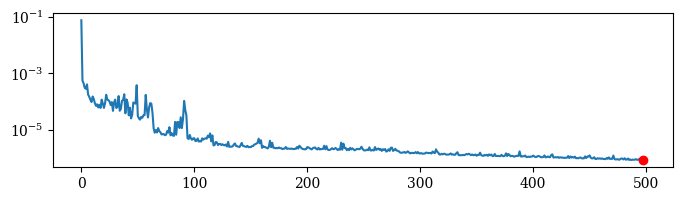

In [13]:
plt.figure(figsize=(8,2))
plt.plot(losses)
plt.yscale('log')
plt.scatter(best_epoch,losses[best_epoch], marker='o',c='red',zorder=2)
plt.show()

# Bifurcation diagram (unsplit model)

Same construction as `figures/bifrucation.ipynb`, but using the trained **unsplit** standard
NODE. Steady states are the roots of `model(x, κ) = 0` (the network *is* `dx/dt`), found in
the model's scaled input space and inverse-transformed for plotting, compared against the
true steady states of `budworm_ode(x; r, κ) = 0`. Fold lines mark the discriminant roots
`r1_sol`, `r2_sol`. The figure is not saved.

In [18]:
from scipy.optimize import root_scalar

# Reuse the trained `model`, `scaler`, `budworm_ode`, control grid `us`, and the
# discriminant roots `r1_sol`, `r2_sol` defined above.
model.eval()

x_lin = np.linspace(0.1, 10, 101)
lam_lin = np.linspace(us[0], us[-1], 501)
x_lin_scaled = scaler.transform(x_lin.reshape(-1, 1)).reshape(-1)


def process_solutions(solutions):
    # Branch values and the lambda-index aligned to each value. Tracking the index
    # explicitly (rather than deriving it from range(...)) keeps values and indices
    # aligned even when some lambda has 0 roots (the unsplit model has no in-range
    # equilibrium at large kappa, where its steady state lies above x = 10).
    x1, x2, x3 = [], [], []   # lower / middle / upper branch
    i1, i2, i3 = [], [], []

    bifur = False

    for idx, sol in enumerate(solutions):
        sol_sorted = np.sort(np.array(sol).flatten())
        n = len(sol_sorted)

        if n == 0:
            # No equilibrium found in range for this lambda; skip it.
            continue

        if n >= 3:
            x1.append(sol_sorted[0]);  i1.append(idx)
            x2.append(sol_sorted[1]);  i2.append(idx)
            x3.append(sol_sorted[-1]); i3.append(idx)
            bifur = True
        elif n == 2:
            if bifur:
                x3.append(sol_sorted[-1]); i3.append(idx)
            else:
                x1.append(sol_sorted[0]);  i1.append(idx)
        else:  # n == 1
            if bifur:
                x3.append(sol_sorted[0]); i3.append(idx)
            else:
                x1.append(sol_sorted[0]); i1.append(idx)

    X = [x1, x2, x3]
    indices = [i1, i2, i3]
    return X, indices

In [19]:
# Unsplit model steady states: solve model(x, kappa) = 0 directly (the network IS dx/dt).
# Root-finding is done in scaled coordinates (the model's native input space).
model_roots = []
for ki in tqdm(lam_lin):
    def objective(x, _k=ki):
        k_torch = torch.tensor([_k], dtype=torch.float32, device='cpu')
        x_torch = torch.tensor([x], dtype=torch.float32, device='cpu')
        with torch.no_grad():
            return model(x_torch, k_torch).squeeze().numpy()

    roots_ki = []
    for i in range(len(x_lin_scaled) - 1):
        if objective(x_lin_scaled[i]) * objective(x_lin_scaled[i + 1]) < 0:  # sign change
            sol = root_scalar(objective, bracket=[x_lin_scaled[i], x_lin_scaled[i + 1]], method='bisect')
            roots_ki.append(sol.root)
    model_roots.append(roots_ki)

  0%|          | 0/501 [00:00<?, ?it/s]

In [20]:
# True steady states: roots of budworm_ode(x; r_val, kappa) = 0 (physical coordinates).
true_roots = []
for ki in tqdm(lam_lin):
    objective = lambda x: budworm_ode(0, x, r_val, ki)
    roots = []
    for i in range(len(x_lin) - 1):
        if objective(x_lin[i]) * objective(x_lin[i + 1]) < 0:  # sign change
            sol = root_scalar(objective, bracket=[x_lin[i], x_lin[i + 1]], method='bisect')
            roots.append(sol.root)
    true_roots.append(roots)

  0%|          | 0/501 [00:00<?, ?it/s]

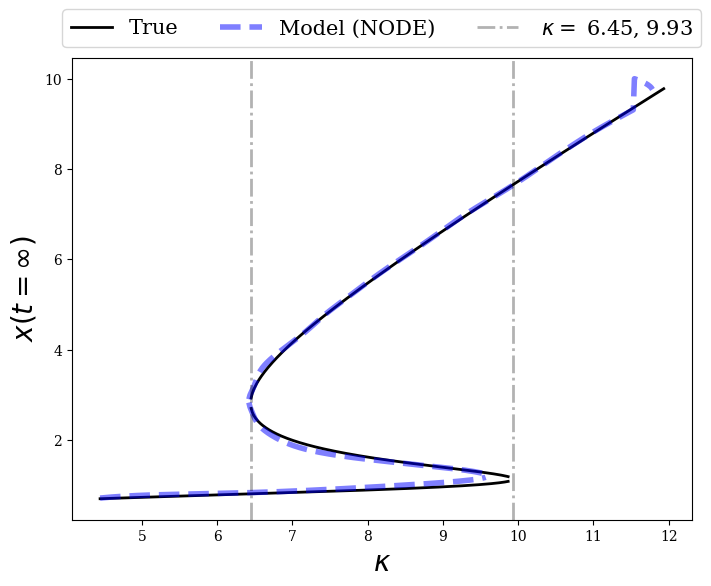

In [21]:
plt.figure(figsize=(8, 6))

x_star, idx = process_solutions(true_roots)
for k, (xi, idx_i) in enumerate(zip(x_star, idx)):
    plt.plot(lam_lin[idx_i], xi,
             c='black', lw=2, zorder=1,
             label="True" if k == 0 else None)

x_star, idx = process_solutions(model_roots)
for k, (xi, idx_i) in enumerate(zip(x_star, idx)):
    xi = scaler.inverse_transform(np.array(xi).reshape(-1, 1))
    plt.plot(lam_lin[idx_i], xi,
             c='blue', linestyle='--', alpha=0.5, lw=4, zorder=2,
             label=r"Model (NODE)" if k == 0 else None)

plt.axvline(float(r1_sol), c='black', linestyle="-.", alpha=0.3, lw=2)
plt.axvline(float(r2_sol), c='black', linestyle="-.", alpha=0.3, lw=2,
            label=rf" $\kappa =$ {float(r1_sol):.2f}, {float(r2_sol):.2f}")

plt.xlabel(r"$\kappa$", fontsize=20)
plt.ylabel(r"$x(t = \infty)$", fontsize=20)

plt.legend(fontsize=15, ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1))
# Image intentionally not saved.
plt.show()

## Steady-state stability — Jacobian eigenvalues

For each steady state we report the eigenvalue of the 1×1 Jacobian. For the unsplit model
this is `d model/dx` at the (scaled) steady state; for the true system it is
`d/dx [ r·x(1 − x/κ) − x²/(1+x²) ] = r·(1 − 2x/κ) − 2x/(1+x²)²`. A negative eigenvalue
indicates a **stable** steady state. The MinMax scaling cancels in the chain rule, so the
model's scaled Jacobian equals the physical one — making the model and true eigenvalues
directly comparable.

In [22]:
from torch.autograd.functional import jacobian as torch_jacobian

# Flat array, one row per MODEL steady state:
#   columns = [kappa, x*_scaled, x*_unscaled, eigenvalue, is_stable]
# 1-D Jacobian of the unsplit model: d model(x, kappa) / dx at the (scaled) steady state.
# (The MinMax scaling cancels in the chain rule, so this equals the physical Jacobian.)
model.eval()
model_stability_rows = []
for ki, roots_ki in zip(lam_lin, model_roots):
    k_t = torch.tensor([ki], dtype=torch.float32)
    for r in roots_ki:
        x_t = torch.tensor([r], dtype=torch.float32)
        J = torch_jacobian(lambda x: model(x, k_t), x_t)  # shape [1, 1]
        eig = np.linalg.eigvals(J.detach().numpy()).real[0]
        x_unscaled = scaler.inverse_transform(np.array([[r]]))[0, 0]
        model_stability_rows.append([ki, r, x_unscaled, eig, float(eig < 0)])

model_stability = np.array(model_stability_rows)
print("model_stability columns: [kappa, x*_scaled, x*_unscaled, eigenvalue, is_stable]")
print("shape:", model_stability.shape)
print(f"stable: {int(model_stability[:, 4].sum())} / {len(model_stability)}")

model_stability columns: [kappa, x*_scaled, x*_unscaled, eigenvalue, is_stable]
shape: (930, 5)
stable: 702 / 930


In [23]:
# Flat array, one row per TRUE steady state:
#   columns = [kappa, x*, eigenvalue, is_stable]
# True 1-D Jacobian of budworm_ode wrt x (r = r_val fixed, k = kappa):
#   d/dx [ r*x*(1 - x/k) - x**2/(1+x**2) ] = r*(1 - 2*x/k) - 2*x/(1+x**2)**2
true_stability_rows = []
for ki, roots_ki in zip(lam_lin, true_roots):
    for xr in roots_ki:
        eig = r_val * (1.0 - 2.0 * xr / ki) - 2.0 * xr / (1.0 + xr ** 2) ** 2
        true_stability_rows.append([ki, xr, eig, float(eig < 0)])

true_stability = np.array(true_stability_rows)
print("true_stability columns: [kappa, x*, eigenvalue, is_stable]")
print("shape:", true_stability.shape)
print(f"stable: {int(true_stability[:, 3].sum())} / {len(true_stability)}")

true_stability columns: [kappa, x*, eigenvalue, is_stable]
shape: (959, 4)
stable: 730 / 959


In [24]:
model_stability

array([[ 4.44569072,  0.06265015,  0.72023645, -0.24454534,  1.        ],
       [ 4.46066817,  0.06289673,  0.72267761, -0.24387825,  1.        ],
       [ 4.47564561,  0.06313843,  0.72507043, -0.24320364,  1.        ],
       ...,
       [11.76965935,  0.979646  ,  9.79849536,  0.18789384,  0.        ],
       [11.78463679,  0.96417725,  9.64535474, -0.10000686,  1.        ],
       [11.78463679,  0.9757959 ,  9.76037939,  0.1083187 ,  0.        ]])

In [25]:
true_stability

array([[ 4.44569072,  0.70574537, -0.24673916,  1.        ],
       [ 4.46066817,  0.70660128, -0.24610482,  1.        ],
       [ 4.47564561,  0.70745572, -0.24547187,  1.        ],
       ...,
       [11.90445632,  9.74597778, -0.35904084,  1.        ],
       [11.91943376,  9.76163367, -0.35934974,  1.        ],
       [11.9344112 ,  9.77728699, -0.35965767,  1.        ]])

In [29]:
model_stability[:, -1]-true_stability[:930, -1]

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0., -1.,  0.,  1., -1.,  0.,  1., -1.,  0.,  1., -1.,
        0.,  1., -1.,  0.,  1., -1.,  0.,  1., -1.,  0.,  1., -1.,  0.,
        1., -1.,  0.,  1., -1.,  0.,  1., -1.,  0.,  1., -1.,  0.,  1.,
       -1.,  0.,  1., -1.,  0.,  1., -1.,  0.,  1., -1.,  0.,  1